# 17 -- Checkpoint/resume validation: extend a real scan, compare against a fresh one

Validates the checkpointing scheme the way it's actually used in production
-- not a synthetic single-row test, but the same `15_runtime_scan_setup.ipynb`
workflow you'd run for real, extending a real scan's `GAMMA_STAR_MAX`.

**Setup (run these in `15_runtime_scan_setup.ipynb`, in order):**
1. `GAMMA_STAR_MIN=1.0, GAMMA_STAR_MAX=4.0, KR_MIN=1.0, KR_MAX=20.0, N_OMEGA=8,
   EXTEND_FROM=None`. Submit the SLURM script, wait for it to finish. This
   writes `data/runtime_scan_lb0.84_gs1-4_kR1-20_nw8/`.

   (`KR_MIN`/`KR_MAX`/`N_OMEGA` are deliberately small here, not production
   values -- this only needs to be cheap to run twice, not physically
   comprehensive.)

2. Same inputs but `GAMMA_STAR_MAX=5.0`, `EXTEND_FROM=None` -- an
   INDEPENDENT, from-scratch scan at the target size. Submit, wait. This
   writes a SECOND `data/runtime_scan_lb0.84_gs1-5_kR1-20_nw8/` -- the
   ground truth this notebook validates against.

3. Run **Section 1** below to rename that ground-truth scan out of the way
   (its directory name will otherwise collide with step 4's output).

4. Back in notebook 15: `GAMMA_STAR_MAX=5.0`,
   `EXTEND_FROM=ROOT/'data/runtime_scan_lb0.84_gs1-4_kR1-20_nw8'`. Submit
   the (regenerated) SLURM script, wait. This renames the gs1-4 scan to
   `gs1-5`, extends its 24 existing rows' `times[]` in place (Format A --
   each row's own embedded plateau checkpoint seeds it, no re-integration
   from `s=0`), and computes the 7 newly-in-range rows fresh.

5. Run **Section 2** below to compare a few representative rows between the
   two `gs1-5` scans (extended vs. built fresh) at their shared `T_MAX`.

If checkpointing is correct, the extended scan's rows should trace the same
GW spectrum as the independently-built one, even though (see Section 2) the
exact `gamma_ij` values and `wlist` grids won't be bit-identical between the
two scans.

In [1]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

import ptbuilder as pt

ROOT = Path(pt.__file__).parent.parent
TAG  = 'lb0.84_gs1-5_kR1-20_nw8'   # must match notebook 15's tag for step 2/4 above

DIRECT_SCAN   = ROOT / 'data' / f'runtime_scan_{TAG}_direct'    # renamed in Section 1
EXTENDED_SCAN = ROOT / 'data' / f'runtime_scan_{TAG}'           # written by notebook 15 step 4

GAMMA_IJ_TARGETS = [1.0, 2.5, 5.0]

## 1. Rename the ground-truth scan out of the way

Run this right after notebook 15's step 2 (fresh `gs1-5`) finishes, and
BEFORE step 4 (extend `gs1-4` -> `gs1-5`) -- otherwise step 4 will refuse to
proceed (it errors rather than overwriting an existing directory).

In [2]:
fresh_gs1_5 = ROOT / 'data' / f'runtime_scan_{TAG}'

if DIRECT_SCAN.exists():
    print(f'{DIRECT_SCAN.name} already exists -- nothing to do.')
elif fresh_gs1_5.exists():
    fresh_gs1_5.rename(DIRECT_SCAN)
    print(f'Renamed {fresh_gs1_5.name} -> {DIRECT_SCAN.name}')
else:
    raise FileNotFoundError(
        f'Neither {DIRECT_SCAN.name} nor {fresh_gs1_5.name} exists -- run notebook 15 '
        f'step 2 (fresh GAMMA_STAR_MAX=5.0 scan) and wait for it to finish first.')

runtime_scan_lb0.84_gs1-5_kR1-20_nw8_direct already exists -- nothing to do.


## 2. Compare a few rows between the two `gs1-5` scans

For each target `gamma_ij`, finds the nearest row in EACH scan independently
-- the two scans' `gamma_ij` grids are not bit-identical (the extended
scan's first 24 rows are exactly the old `gs1-4` scan's rows; the direct
scan recomputes its own grid from scratch over the full `[1, 12.5]` range),
so this is a nearest-match, not an exact index match. Same reasoning
applies to `wlist`: the extended scan's rows keep their original frequency
grid (anchored to the OLD `GAMMA_STAR_MAX=4`), while the direct scan's rows
get one anchored to the NEW `GAMMA_STAR_MAX=5` -- see notebook 15's
`OMEGA_MIN_GAMMA_FACTOR` cell. Both scans share the same global `T_MAX`
(fixed by `GAMMA_STAR_MAX=5` alone), so each row's LAST result file is
directly comparable in time even though the two rows aren't exactly the
same `gamma_ij` or `w` grid.

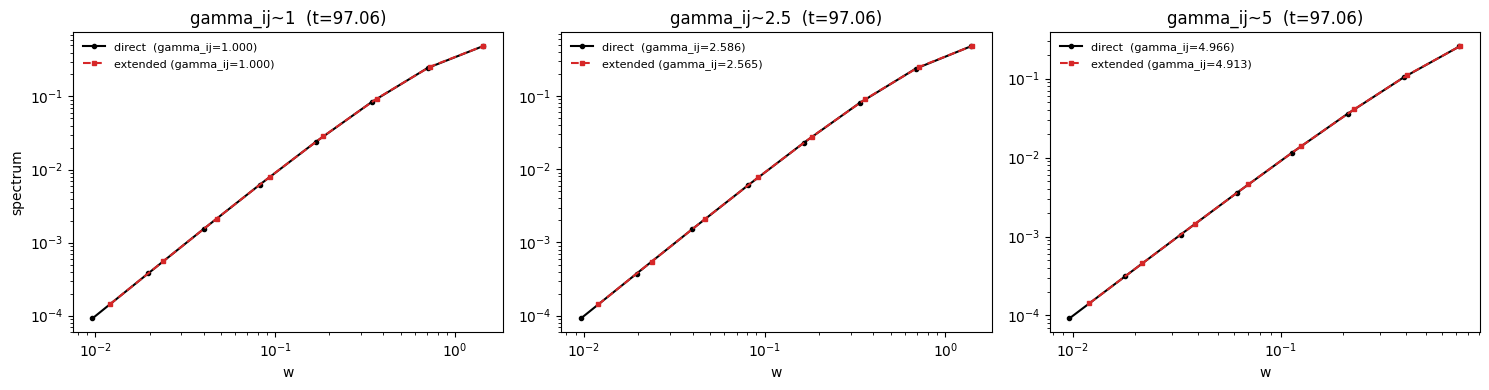

In [3]:
def load_manifest(scan_root):
    rows = []
    with open(scan_root / 'manifest.tsv') as f:
        next(f)   # header
        for line in f:
            index, gamma, n_t, setup, name = line.rstrip('\n').split('\t')
            rows.append(dict(index=int(index), gamma_ij=float(gamma), n_t=int(n_t),
                             setup=ROOT / setup, name=name))
    return rows

def nearest_row(rows, gamma_target):
    return min(rows, key=lambda r: abs(r['gamma_ij'] - gamma_target))

def load_last_result(scan_root, row):
    last_i_t = row['n_t'] - 1
    path = scan_root / 'gpu' / row['name'] / f'result_{last_i_t:04d}.h5'
    with h5py.File(path) as f:
        return f['w'][:], f['spectrum'][:], float(f.attrs['t'])

for path, label in [(DIRECT_SCAN, 'direct'), (EXTENDED_SCAN, 'extended')]:
    if not path.exists():
        raise FileNotFoundError(f'{path} not found -- see the setup steps in the intro '
                                f'markdown cell ({label} scan missing)')

rows_direct   = load_manifest(DIRECT_SCAN)
rows_extended = load_manifest(EXTENDED_SCAN)

fig, axes = plt.subplots(1, len(GAMMA_IJ_TARGETS), figsize=(5*len(GAMMA_IJ_TARGETS), 4))
if len(GAMMA_IJ_TARGETS) == 1:
    axes = [axes]

for ax, gamma_target in zip(axes, GAMMA_IJ_TARGETS):
    row_d = nearest_row(rows_direct, gamma_target)
    row_e = nearest_row(rows_extended, gamma_target)

    if not (EXTENDED_SCAN / 'gpu' / row_e['name'] / f"result_{row_e['n_t']-1:04d}.h5").exists():
        raise FileNotFoundError(
            f"extended scan row gamma_ij={row_e['gamma_ij']:.3f} has no final result -- "
            f"wait for notebook 15 step 4's SLURM job to finish")
    if not (DIRECT_SCAN / 'gpu' / row_d['name'] / f"result_{row_d['n_t']-1:04d}.h5").exists():
        raise FileNotFoundError(
            f"direct scan row gamma_ij={row_d['gamma_ij']:.3f} has no final result -- "
            f"wait for notebook 15 step 2's SLURM job to finish")

    w_d, spec_d, t_d = load_last_result(DIRECT_SCAN, row_d)
    w_e, spec_e, t_e = load_last_result(EXTENDED_SCAN, row_e)

    assert abs(t_d - t_e) < 1e-6 * max(1.0, abs(t_d)), (
        f'direct t={t_d:.6f} != extended t={t_e:.6f} at gamma_ij~{gamma_target} -- '
        f'both scans should share the same global T_MAX')

    ax.plot(w_d, spec_d, 'o-', color='k', lw=1.5, ms=3,
           label=f"direct  (gamma_ij={row_d['gamma_ij']:.3f})")
    ax.plot(w_e, spec_e, 's--', color='tab:red', lw=1.5, ms=3,
           label=f"extended (gamma_ij={row_e['gamma_ij']:.3f})")
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('w')
    ax.set_title(f'gamma_ij~{gamma_target:g}  (t={t_d:.2f})')
    ax.legend(frameon=False, fontsize=8)

axes[0].set_ylabel('spectrum')
plt.tight_layout()
plt.savefig(ROOT / 'checkpoint_validation_scan_extend.pdf', bbox_inches='tight')
plt.show()